<a href="https://colab.research.google.com/github/Muhammad-Waleed-Source/Machine-Learning/blob/main/Day-13/Toy-Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Creating a Logistic Regression Model(Classification) to calssify either the student got placement or not based on cgpa and iq.

In [16]:
import numpy as np
import pandas as pd

In [17]:
df = pd.read_csv('placement.csv')

In [18]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [20]:
df.shape

(100, 4)

In [21]:
df.iloc[:, 1:]

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [22]:
df = df.iloc[:, 1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [23]:
df.shape

(100, 3)

## Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

## 0. Preprocess + EDA + Feature Selection

### preprocessing

In [24]:
df.info()

# there are no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
# also we have removed the index col, so preprocessing is done

### EDA

In [25]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'iq')

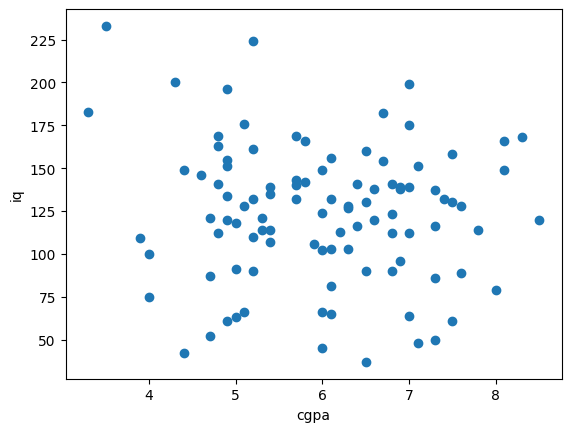

In [28]:
plt.scatter(df['cgpa'], df['iq'])

plt.xlabel('cgpa')
plt.ylabel('iq')

Text(0, 0.5, 'iq')

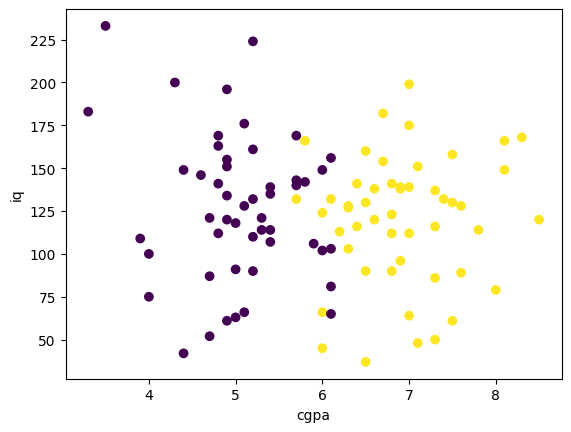

In [29]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

plt.xlabel('cgpa')
plt.ylabel('iq')

- Most purple points are on the left.
- Most yellow points are on the right.
- A few points overlap or fall on the wrong side.

So the data is not perfectly linearly separable, but it is roughly linearly separable.

We can draw a single straight line that separates most points from the two classes.

### feature selection

In [ ]:
# as both input cols(cgpa and iq) is required here, so no need for this step.

## 1. Extract input and output cols

In [30]:
X = df.iloc[: , 0:2]
y = df.iloc[:, -1]

In [31]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [34]:
X.shape

# a 2D Tensor(matrix)

(100, 2)

In [32]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [35]:
y.shape

# 1D Tensor(vector)

(100,)

## 3. Train test split

Doing train test split step first because if we scale the values now, we would not know which data is which set(train, test and split).

Just to see (Nothing special)

In [36]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

# test_size=0.1 means extract 10% values and place it in test

In [50]:
print(X_train)

    cgpa     iq
29   7.0  112.0
42   7.6   89.0
54   6.4  141.0
49   5.4  135.0
35   6.8   90.0
..   ...    ...
34   4.8  163.0
21   7.1  151.0
32   7.0  139.0
82   6.5   37.0
65   8.1  166.0

[90 rows x 2 columns]


In [51]:
print(X_test)

    cgpa     iq
5    7.1   48.0
84   5.7  169.0
6    5.7  143.0
51   4.8  141.0
2    5.3  121.0
62   6.0  102.0
45   6.0   66.0
78   6.1   81.0
16   5.2  224.0
24   4.7  121.0


In [53]:
print(y_train)

29    1
42    1
54    1
49    0
35    1
     ..
34    0
21    1
32    1
82    1
65    1
Name: placement, Length: 90, dtype: int64


In [54]:
print(y_test)

5     1
84    0
6     0
51    0
2     0
62    0
45    1
78    0
16    0
24    0
Name: placement, dtype: int64


## 2. Scale the values

In [55]:
from sklearn.preprocessing import StandardScaler

In [57]:
scaler = StandardScaler()

In [58]:
X_train = scaler.fit_transform(X_train)

In [63]:
X_train

array([[ 0.82907854, -0.30603058],
       [ 1.34073844, -0.90253085],
       [ 0.31741864,  0.44607847],
       [-0.53534786,  0.2904697 ],
       [ 0.65852524, -0.87659605],
       [ 1.08490849, -0.98033523],
       [ 0.40269529, -0.87659605],
       [-0.87645446, -0.85066126],
       [-1.473391  ,  1.97623134],
       [ 0.06158869,  0.83510038],
       [-0.10896461, -0.46163934],
       [ 0.74380189,  0.36827408],
       [ 1.08490849,  0.34233929],
       [-0.79117781,  1.35379627],
       [-1.04700775,  1.17225271],
       [-0.87645446, -0.15042181],
       [-0.79117781, -1.49903112],
       [ 0.74380189,  0.39420888],
       [ 1.68184504, -1.16187879],
       [-1.72922095, -1.26561797],
       [-0.27951791,  0.21266532],
       [-1.1322844 , -0.95440044],
       [-0.62062451, -0.25416099],
       [-1.04700775, -0.30603058],
       [ 1.25546179,  0.88696997],
       [-0.53534786,  0.39420888],
       [ 0.23214199, -0.53944373],
       [ 0.06158869, -0.53944373],
       [-0.70590116,

In [64]:
X_test = scaler.transform(X_test)

In [65]:
X_test

array([[ 0.91435519, -1.96585743],
       [-0.27951791,  1.17225271],
       [-0.27951791,  0.49794805],
       [-1.04700775,  0.44607847],
       [-0.62062451, -0.07261742],
       [-0.02368796, -0.56537852],
       [-0.02368796, -1.49903112],
       [ 0.06158869, -1.11000921],
       [-0.70590116,  2.59866641],
       [-1.1322844 , -0.07261742]])

## 4. Train the model

In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
clf = LogisticRegression()

In [68]:
# model training

clf.fit(X_train, y_train)

LogisticRegression()

In [90]:
new_student = np.array([[4, 110]])

new_student = scaler.transform(new_student)

clf.predict(new_student)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

## 5. Evaluate the model

In [73]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 1, 1, 1, 0, 0])

In [74]:
y_test

,placement
5,1
84,0
6,0
51,0
2,0
62,0
45,1
78,0
16,0
24,0


In [72]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

# our model is giving 80% accurate results

0.8

plotting decision boundry

In [75]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

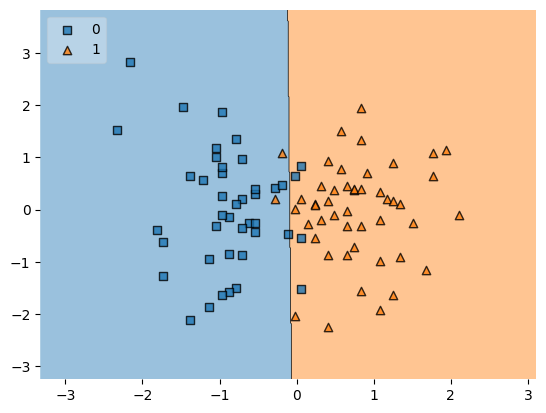

In [76]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

# .values convert pandas series or dataframe to numpy array

## 6. Deploy the model

In [77]:
import pickle

# for converting python objects to a file which we can use in any other environment

In [91]:
pickle.dump(clf, open('model.pkl', 'wb'))
pickle.dump(scaler, open("scaler.pkl", "wb"))

We can use that pickle file to embed it in our website